# DLPFC (12 Visium sections): spatial benchmark, UMAPs, parameter and downstream analyses

Figures of the dorsolateral prefrontal cortex data (12 sections of 3 donors, 47,681 spots; manual layers L1-L6, WM).

| Figure | Output (`figures/dlpfc/`) |
|---|---|
| Spatial benchmark table | `benchmark_results_table.pdf` |
| UMAP per method (section, layer) | `umap_plots/` |
| Spatial weight λs and anchor weight λa of PRIME | `sensitivity_lambda_dlpfc` |
| Setting selection of every spatial method, runtime and memory | `spatial_tuning_resources` |
| Spatial domains and downstream metrics | `dlpfc_downstream` |
| Marker genes of PRIME's domains against the manual layers | `dlpfc_marker_concordance` |

Inputs: `DLPFC_merged.h5ad`; the per-method embeddings and the metric table of `pipeline/benchmark/dlpfc/`
(config `benchmark.dlpfc.results_dir`); and the result tables of `pipeline/prime_analysis/parameter_grid.py`,
`pipeline/spatial/` under `<out_dir>/{sensitivity,ablation,spatial_methods,domains,marker_concordance}/`
(see the script headers).

About 20 min, 40 GB.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

NB_DIR = Path.cwd() if (Path.cwd() / "figlib").is_dir() else Path.cwd() / "notebooks"
sys.path.insert(0, str(NB_DIR))                 # figlib; it adds pipeline/ and the prime package of this checkout

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc

from figlib import config, names
from figlib.display import preview, rel, show_png

CFG = config.load()                             # pipeline/config.yaml (+ config.local.yaml)
BENCH = CFG["benchmark"]                        # saved outputs of pipeline/benchmark/
N_JOBS = CFG["n_jobs"]
sc.settings.n_jobs = N_JOBS

## Spatial benchmark table

wrote figures/dlpfc/benchmark_results_table.pdf


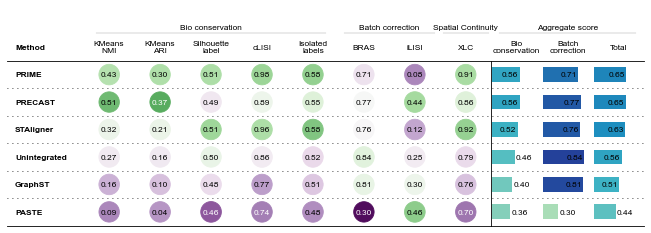

In [2]:
# Spatial benchmark table: the metric table of pipeline/benchmark/dlpfc/benchmark_metrics.py (scIB metrics + XLC),
# aggregated as in that script and drawn with prime.plotting.
from prime.plotting import plot_scib_results_table, save_scib_results_publication_pdf

mpl.rcdefaults()
results_dir = Path(BENCH["dlpfc"]["results_dir"])
results_df = pd.read_csv(f"{results_dir}/benchmark_results_with_xlc.csv", index_col=0)

benchmark_keys = ["STAligner", "paste", "GraphST", "prime", "precast"]
benchmark_keys = [f"X_{method}" for method in benchmark_keys] + ["Unintegrated"]
results_df = results_df.loc[benchmark_keys + ["Metric Type"]].copy()      # the methods of the table

# use Total Score to replace Total
results_df.drop(columns=["Total"], inplace=True)
results_df.rename(columns={"Total Score": "Total"}, inplace=True)

# drop out the KBET and re-calculate the aggregate score
results_df.drop(columns=["KBET"], inplace=True)
BatchCorrection_cols = ["BRAS"]

update_col = results_df.loc[benchmark_keys, BatchCorrection_cols].copy()
update_col = update_col.apply(pd.to_numeric, errors='coerce')

update_col["Batch correction"] = update_col.mean(axis=1)

results_df.loc[benchmark_keys, "Batch correction"] = update_col["Batch correction"]

#  re-calculate the Total score
update_col = results_df.loc[benchmark_keys].copy()
update_col = update_col.apply(pd.to_numeric, errors='coerce')

results_df.loc[benchmark_keys, "Total"] = (
    0.7 * update_col['Bio conservation']
    + 0.05 * update_col['Batch correction']
    + 0.25 * update_col['XLC']
)

results_df.loc["Metric Type", "Total"] = "Aggregate score"

for method in ["prime", "precast", "STAligner", "paste", "GraphST"]:
    results_df.rename(index={f"X_{method}": method.upper() if method in ['prime', 'precast', 'paste'] else method}, inplace=True)

fig, ax, table = plot_scib_results_table(results_df, show=False)
out = config.figure_dir("dlpfc") / "benchmark_results_table.pdf"
save_scib_results_publication_pdf(fig, ax, save_path=out)
print("wrote", rel(out))
preview(fig)

## UMAP of every method

In [3]:
# DLPFC, 12 sections (as pipeline/benchmark/dlpfc/umap_plots.py): unintegrated PCA, and the saved embeddings of the
# spatial methods (benchmark.dlpfc.results_dir).
import os

mpl.rcdefaults()
adata = sc.read_h5ad(CFG["datasets"]["dlpfc"]["path"])
adata.obs['section'] = adata.obs['sample'].copy()

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=3000, flavor='seurat_v3')
adata_tmp = adata[:, adata.var['highly_variable']].copy()
sc.pp.scale(adata_tmp, max_value=10)
sc.tl.pca(adata_tmp, n_comps=50, svd_solver='arpack')
adata.obsm['Unintegrated'] = adata_tmp.obsm['X_pca']
del adata_tmp

save_dir = Path(BENCH["dlpfc"]["results_dir"])
precast_df = pd.read_csv(f"{save_dir}/PRECAST_embedding_with_meta.csv")
precast_df['key'] = precast_df['section'].astype(str) + '_' + precast_df['barcode'].astype(str)
embedding_cols = [f"PRECAST_{i}" for i in range(1, 16)]
precast_df = precast_df.set_index('key')
all_keys = adata.obs['key'].values
missing_keys = set(all_keys) - set(precast_df.index)
mean_embedding = precast_df[embedding_cols].mean(axis=0).values
for mk in missing_keys:
    precast_df.loc[mk, embedding_cols] = mean_embedding
    section_val = adata.obs.loc[adata.obs['key'] == mk, 'section'].iloc[0]
    barcode_val = adata.obs.loc[adata.obs['key'] == mk, 'barcode'].iloc[0]
    precast_df.loc[mk, 'section'] = section_val
    precast_df.loc[mk, 'barcode'] = barcode_val
adata.obsm['X_precast'] = precast_df.loc[all_keys, embedding_cols].values

results_dir = save_dir
for method in ["STAligner", "paste", "GraphST", "prime"]:
    embedding_file = os.path.join(results_dir, f"{method}_embedding.npy")
    if os.path.exists(embedding_file):
        adata.obsm[f"X_{method}"] = np.load(embedding_file)
        print(f"Loaded embedding for {method}")
    else:
        print(f"Embedding file for {method} not found")

Loaded embedding for STAligner
Loaded embedding for paste


Loaded embedding for GraphST
Loaded embedding for prime


wrote X_STAligner


wrote X_paste


wrote X_GraphST


wrote X_prime


wrote X_precast


wrote Unintegrated
prime_umap_section.png


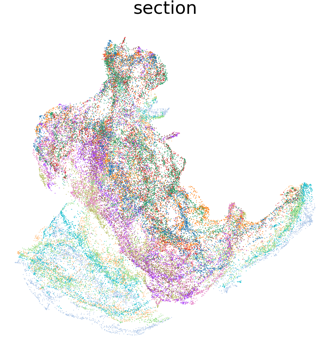

prime_umap_layer_guess.png


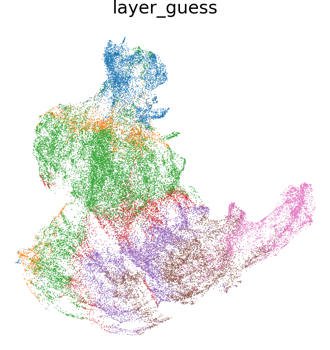

In [4]:
from figlib.umap_png import DEFAULT_UMAP_FIGSIZE, PNG_DPI, save_method_umap_pngs   # PNG_DPI = 300 in this script

save_dir = config.figure_dir("dlpfc", "umap_plots")
CACHE = config.cache_dir("dlpfc")


def umap_of(key):
    f = CACHE / f"{key}_umap.npy"
    if not f.exists():
        sc.pp.neighbors(adata, use_rep=key, n_neighbors=15)
        sc.tl.umap(adata, min_dist=0.3, spread=1.0)
        np.save(f, adata.obsm["X_umap"])
    return np.load(f)


adata.obsm["X_umap"] = umap_of("Unintegrated")
with mpl.rc_context({"figure.dpi": PNG_DPI, "savefig.dpi": PNG_DPI, "pdf.fonttype": 42, "ps.fonttype": 42,
                     "font.family": "Arial"}):
    for color in ("section", "layer_guess"):
        fig, ax = plt.subplots(figsize=DEFAULT_UMAP_FIGSIZE)
        sc.pl.umap(adata, color=color, ax=ax, show=False)
        fig.savefig(save_dir / f"Unintegrated_umap_{color}.pdf", dpi=PNG_DPI, transparent=True, bbox_inches="tight",
                    pad_inches=0, facecolor=fig.get_facecolor())
        plt.close(fig)

benchmark_keys = ["X_STAligner", "X_paste", "X_GraphST", "X_prime", "X_precast", "Unintegrated"]
for method in benchmark_keys:
    adata.obsm["X_umap"] = umap_of(method)
    save_method_umap_pngs(adata, colors=("section", "layer_guess"), data_path=save_dir,
                          method_slug=method.replace("X_", ""), png_dpi=PNG_DPI)
    print("wrote", method)
show_png(save_dir / "prime_umap_section.png", save_dir / "prime_umap_layer_guess.png", max_px=350)

## Parameter sensitivity, setting selection and downstream analyses

Drawn from the result tables under `out_dir` of the pipeline configuration.

In [5]:
# Style and helpers of the analysis figures (figlib/style.py): palette, save, panel, load, sweep, ...
# OUT = out_dir of the pipeline configuration (result tables); figures are written to figures/dlpfc/.
import figlib.style as S
from figlib.style import *          # CFG, OUT, C (pipeline/common.py), palette, save, panel, load, sweep, ...
S.set_figure_dir(config.figure_dir("dlpfc"))


def draw(fn, name):
    S.apply_style()
    fn()
    png = S.FIG / f"{name}.png"
    if png.exists():
        show_png(png, max_px=1100)
    else:
        print(f"{name}: input tables not found under out_dir; figure skipped")

### Spatial and anchor weights

Spatial weight λs and anchor weight λa of `prime_st` (one factor at a time around the default setting).

In [6]:
def fig_sensitivity_lambda_dlpfc():
    """Spatial weight λs and anchor weight λa (panels a, b)."""
    df = load("sensitivity/dlpfc/results_task*.tsv")
    if df is None:
        return
    default = CFG["datasets"]["dlpfc"]["default"]
    metrics = [("KMeans NMI", "KMeans NMI"), ("KMeans ARI", "KMeans ARI"), ("iLISI", "iLISI (section mixing)"),
               ("XLC", "XLC")]
    fig, axes = plt.subplots(1, 2, figsize=(6.2, 2.6))
    for ax, p, lab, letter in ((axes[0], "lambda_spatial", "Spatial weight λs", "a"),
                               (axes[1], "lambda_anchor", "Anchor weight λa", "b")):
        sub = sweep(df, default, p)
        for (m, mlab), col in zip(metrics, SLOT):
            line_with_band(ax, sub, m, col, mlab)
        ax.axvline(default[p], color=INK2, lw=0.8, ls="--")
        plain_log_ticks(ax, sub["value"].unique(), keep=default[p])
        ax.set_xlabel(lab)
        ax.set_ylim(-0.02, 1.0)
        panel(ax, letter)
    axes[0].set_ylabel("Score (DLPFC, 12 sections)")
    h, l = axes[1].get_legend_handles_labels()
    h.append(mpl.lines.Line2D([], [], color=INK2, ls="--", lw=0.8))
    l.append("default setting")
    fig.legend(h, l, loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize=6)
    fig.tight_layout()
    save(fig, "sensitivity_lambda_dlpfc")

wrote figures/dlpfc/sensitivity_lambda_dlpfc


sensitivity_lambda_dlpfc.png


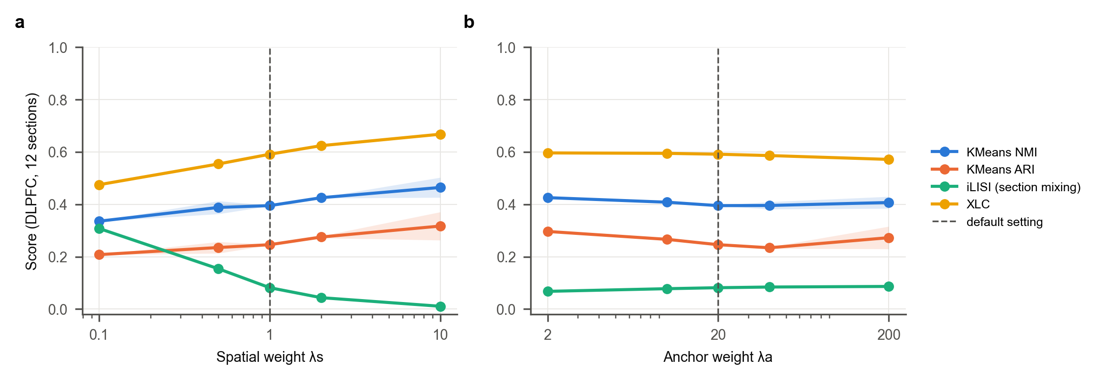

In [7]:
draw(fig_sensitivity_lambda_dlpfc, "sensitivity_lambda_dlpfc")

### Setting selection and resources

Development-donor score of every setting of every spatial method (a), default against selected setting on the
evaluation donors (b), runtime and memory (c).

In [8]:
def fig_spatial_tuning_resources():
    log = OUT / "spatial_methods/tuning_log.tsv"
    default, _ = domain_table("emb_s*")
    tuned, _ = domain_table("tuned_emb_s*")
    if not log.exists():
        return
    names = {"prime": "PRIME", "precast": "PRECAST", "graphst": "GraphST", "staligner": "STAligner",
             "spabatch": "SpaBatch"}                                  # SpaCross / SpaMask not shown (per-donor only)
    tun = pd.read_csv(log, sep="\t")
    tun = tun[tun.method.isin(names)]
    sel = pd.read_csv(OUT / "spatial_methods/tuning_selected.tsv", sep="\t")
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.0), gridspec_kw={"width_ratios": [1.3, 1.1, 1.1]})
    ax = axes[0]
    order = tun.groupby("method")["score"].max().sort_values().index
    for y, m in enumerate(order):
        t = tun[tun.method == m]
        base = sel.loc[sel.method == m, "base_setting"].iloc[0]
        ax.scatter(t["score"], [y] * len(t), s=14, color=GREY, zorder=2)
        b = t[t.setting == base]
        ax.scatter(b["score"], [y] * len(b), s=34, facecolor="none", edgecolor=INK, lw=1, zorder=3)
        best = t.loc[t["score"].idxmax()]
        ax.scatter([best["score"]], [y], s=26, color=SLOT[0] if m == "prime" else INK, zorder=4)
        ax.annotate(best["setting"], (best["score"], y), fontsize=5.5, xytext=(3, 3), textcoords="offset points")
    ax.set_yticks(range(len(order)), [names[m] for m in order])
    ax.set_xlabel("Development-donor score (Br5292 only)\n(mean of per-slice ARI and held-out-slice accuracy)")
    ax.grid(axis="y", visible=False)
    panel(ax, "a")
    ax = axes[1]
    if tuned is not None:
        dev = CFG["datasets"]["dlpfc"]["dev_donor"]
        def ev(d):
            c = d[(d.seed >= 0) & (d.clustering == "gmm") & (d.donor != dev)]
            return c.groupby(["method", "emb"])["ARI"].mean().groupby("method").agg(["mean", "std"])
        a, b = ev(default), ev(tuned)
        common = b.index.intersection(a.index)
        common = b.loc[common, "mean"].sort_values().index
        for y, m in enumerate(common):
            ax.plot([a.loc[m, "mean"], b.loc[m, "mean"]], [y, y], color=GRID, lw=2, zorder=1)
            ax.errorbar(a.loc[m, "mean"], y, xerr=a.loc[m, "std"], fmt="o", mfc="white", color=INK2, ms=4, lw=0.8)
            ax.errorbar(b.loc[m, "mean"], y, xerr=b.loc[m, "std"], fmt="o",
                        color=SLOT[0] if m == "PRIME" else INK, ms=4, lw=0.8)
        ax.set_yticks(range(len(common)), common)
        ax.set_xlabel("GMM ARI, evaluation donors\n(open = default, filled = selected; mean ± SD, 5 seeds)")
        ax.grid(axis="y", visible=False)
    panel(ax, "b")
    ax = axes[2]
    rows = []
    for m in names:
        f = OUT / f"spatial_methods/{m}/runs.tsv"
        if f.exists():
            rows.append(pd.read_csv(f, sep="\t").assign(method=m))
    runs = pd.concat(rows, ignore_index=True)
    ok = runs[(runs["status"].astype(str) == "ok") & runs["config"].isin(["default", "donor"])]
    ok = ok[~((ok.method == "spabatch") & (ok.config == "donor"))]
    t = ok.groupby("method")[["seconds", "peak_gb"]].median()
    abl = load("ablation/dlpfc/results_task*.tsv")                 # PRIME default = the "full" ablation variant (same parameters)
    t.loc["prime"] = abl[abl.names == "full"][["seconds", "peak_gb"]].median()
    ax.scatter(t["seconds"] / 60, t["peak_gb"], s=22, color=[SLOT[0] if i == "prime" else GREY for i in t.index])
    for i, r in t.iterrows():
        off = {"precast": (4, -9), "staligner": (4, 3)}.get(i, (4, 2))
        ax.annotate(names[i], (r["seconds"] / 60, r["peak_gb"]), fontsize=6, xytext=off, textcoords="offset points")
    ax.set_xscale("log")
    ax.set_xlabel("Runtime per DLPFC run, 12 slices (min)")
    ax.set_ylabel("Peak host memory (GB)")
    panel(ax, "c")
    fig.tight_layout()
    save(fig, "spatial_tuning_resources")


NICE = {"SpaBatch_donor": "SpaBatch (per donor)", "SpaCross_donor": "SpaCross (per donor)",
        "SpaMask_donor": "SpaMask (per donor)"}


def domain_table(layer="emb_s*"):
    d = load(f"domains/{layer}/per_slice.tsv")
    if d is None:
        return None, None
    d["emb"] = d["_file"].str.extract(r"/((?:tuned_)?emb_s\d+)/")[0]
    tr = load(f"domains/{layer}/donor_transfer.tsv")
    return d, tr

wrote figures/dlpfc/spatial_tuning_resources


spatial_tuning_resources.png


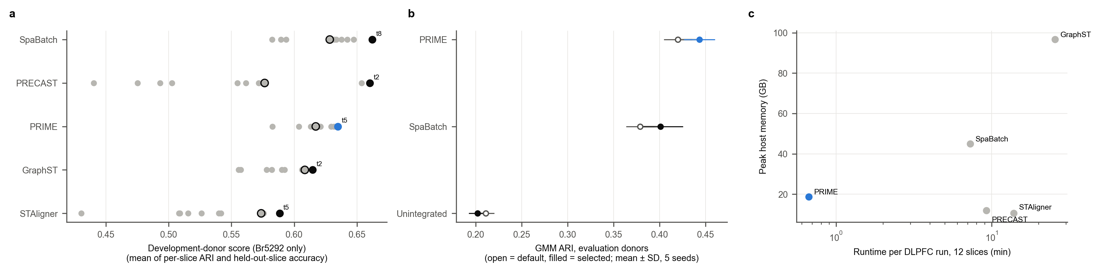

In [9]:
draw(fig_spatial_tuning_resources, "spatial_tuning_resources")

### Spatial domains and downstream metrics

Domains of PRIME and SpaBatch (section 151673) and downstream metrics, default against selected setting.

In [10]:
DOMAIN_METHODS = ["PRIME", "SpaBatch", "Unintegrated"]


def domain_summary(layer):
    """Per method: mean and SD over embedding seeds of the downstream metrics (evaluation donors)."""
    dev = CFG["datasets"]["dlpfc"]["dev_donor"]
    d, tr = domain_table(layer)
    st = load(f"domains/{layer}/slice_transfer.tsv")
    mc = load(f"domains/{layer}/donor_marker_consistency.tsv")
    for x in (d, tr, st, mc):
        x["emb"] = x["_file"].str.extract(r"/((?:tuned_)?emb_s\d+)/")[0]
    d = d[(d.clustering == "gmm") & (d.donor != dev) & d.method.isin(DOMAIN_METHODS)]
    per = d.groupby(["method", "emb"])[["ARI", "abnormal_spots", "marker_effect_size"]].mean()
    per["slice_transfer"] = st[(st.donor != dev)].groupby(["method", "emb"])["accuracy"].mean()
    per["donor_transfer"] = tr.groupby(["method", "emb"])["accuracy"].mean()          # all three held-out donors
    per["marker_consistency"] = mc[mc.clustering == "gmm"].groupby(["method", "emb"])["r"].mean()
    per = per.reset_index()
    per = per[per.method.isin(DOMAIN_METHODS)]
    return per.groupby("method").mean(numeric_only=True), per.groupby("method").std(numeric_only=True)


def fig_dlpfc_downstream():
    if not glob.glob(str(OUT / "domains/tuned_emb_s0/domains_PRIME_s0.tsv")):
        return
    (dm, ds), (tm, ts) = domain_summary("emb_s*"), domain_summary("tuned_emb_s*")
    fig = plt.figure(figsize=(8.6, 5.2))
    gs = fig.add_gridspec(2, 4, height_ratios=[1.0, 0.9], hspace=0.5, wspace=0.45)
    adata = C.load_dataset("dlpfc", CFG)
    xy = np.asarray(adata.obsm["spatial"])
    s = "151673"
    k = (adata.obs["batch"].astype(str) == s).to_numpy()
    rank = adata.obs["label"].astype(str).map({"Layer1": 1, "Layer2": 2, "Layer3": 3, "Layer4": 4, "Layer5": 5,
                                               "Layer6": 6, "WM": 7}).to_numpy(dtype=float)
    layer_cols = mpl.colors.ListedColormap([SEQ(v) for v in np.linspace(0.0, 1.0, 7)])
    maps = [("Manual layers", rank)]
    for m in DOMAIN_METHODS:
        dom = pd.read_csv(OUT / f"domains/tuned_emb_s0/domains_{m}_s0.tsv", sep="\t")["gmm"].to_numpy()
        lab = np.isfinite(rank)
        mapped = pd.Series(rank[lab]).groupby(dom[lab]).agg(lambda r: r.mode().iloc[0])
        maps.append((m, pd.Series(dom).map(mapped).to_numpy()))
    for n, (title, v) in enumerate(maps):
        ax = fig.add_subplot(gs[0, n])
        ax.scatter(xy[k, 0], -xy[k, 1], c=v[k], cmap=layer_cols, vmin=0.5, vmax=7.5, s=1.2, linewidths=0)
        ax.set_title(title, fontsize=7)
        ax.set_aspect("equal")
        ax.axis("off")
        if n == 0:
            panel(ax, "a")
    handles = [mpl.patches.Patch(color=c, label=L) for L, c in zip(["L1", "L2", "L3", "L4", "L5", "L6", "WM"], layer_cols.colors)]
    fig.legend(handles=handles, loc="upper center", ncol=7, bbox_to_anchor=(0.5, 0.585), fontsize=6,
               title="Domains (GMM, K = 7) coloured by their majority manual layer; slice 151673, evaluation donor Br8100",
               title_fontsize=6.5)
    panels = [("ARI", "GMM ARI vs manual layers"), ("abnormal_spots", "Abnormal spots\n(lower = coherent)"),
              ("marker_effect_size", "Layer-marker effect\n(Cohen's d)"),
              ("slice_transfer", "Held-out slice accuracy\n(cross-section alignment)")]
    for n, (metric, xl) in enumerate(panels):
        ax = fig.add_subplot(gs[1, n])
        for y, m in enumerate(DOMAIN_METHODS[::-1]):
            col = SLOT[0] if m == "PRIME" else (INK if m == "SpaBatch" else GREY)
            ax.plot([dm.loc[m, metric], tm.loc[m, metric]], [y, y], color=GRID, lw=2, zorder=1)
            ax.errorbar(dm.loc[m, metric], y, xerr=ds.loc[m, metric], fmt="o", mfc="white", color=col, ms=4, lw=0.8)
            ax.errorbar(tm.loc[m, metric], y, xerr=ts.loc[m, metric], fmt="o", color=col, ms=4, lw=0.8)
        ax.set_yticks(range(len(DOMAIN_METHODS)), DOMAIN_METHODS[::-1] if n == 0 else [])
        ax.set_ylim(-0.6, len(DOMAIN_METHODS) - 0.4)
        ax.set_xlabel(xl, fontsize=6.5)
        ax.grid(axis="y", visible=False)
        panel(ax, "bcde"[n])
    fig.text(0.5, -0.03, "Open = default setting, filled = setting selected on the development donor; mean ± SD over five "
             "embedding seeds;\nevaluation donors Br5595 and Br8100", ha="center", fontsize=6, color=INK2)
    save(fig, "dlpfc_downstream")

wrote figures/dlpfc/dlpfc_downstream


dlpfc_downstream.png


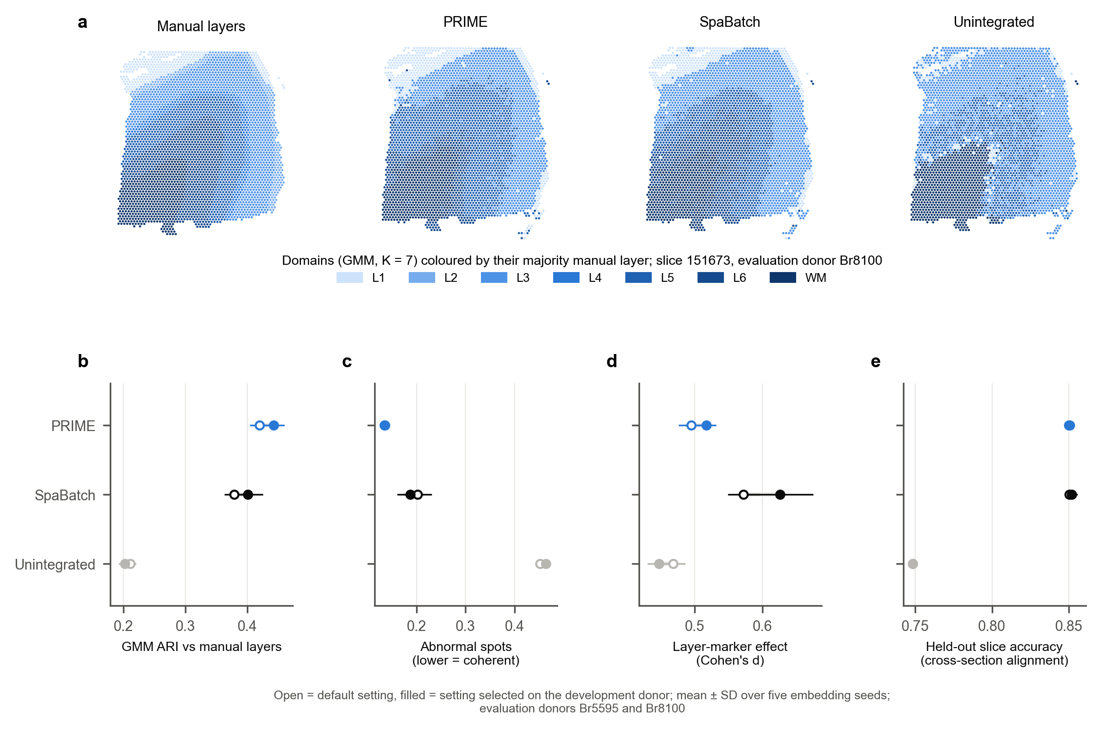

In [11]:
draw(fig_dlpfc_downstream, "dlpfc_downstream")

### Marker genes of the domains

Marker genes and layer markers: manual layers against PRIME's domains.

In [12]:
MC_LAYERS = ["Layer1", "Layer2", "Layer3", "Layer4", "Layer5", "Layer6", "WM"]


MC_SHORT = dict(zip(MC_LAYERS, ["L1", "L2", "L3", "L4", "L5", "L6", "WM"]))


MC_SECTIONS = [("151507", "Br5292"), ("151669", "Br5595"), ("151673", "Br8100")]


MC_DOM_COLS = ["#2a78d6", "#1baf7a", "#eda100", "#eb6834", "#e87ba4", "#4a3aa7", "#008300"]


def mc_domains(tcor):
    """Order PRIME domains by the manual layer whose marker programme they match best (t correlation);
    returns order, display names (D1..D7) and best layer / r per domain."""
    best, r = tcor.idxmax(axis=1), tcor.max(axis=1)
    order = sorted(tcor.index, key=lambda d: (MC_LAYERS.index(best[d]), -r[d]))
    return order, {d: f"D{i + 1}" for i, d in enumerate(order)}, best, r


def fig_dlpfc_marker_concordance():
    marker_concordance = OUT / "marker_concordance"
    sh = marker_concordance / "showcase"
    if not (marker_concordance / "donor_consistency.tsv").exists():
        return
    tcor = pd.read_csv(sh / "tcor.tsv", sep="\t", index_col=0)
    tcor.index = tcor.index.astype(str)
    spots = pd.read_csv(sh / "spots.tsv.gz", sep="\t", dtype={"domain": str, "section": str})
    dot = pd.read_csv(sh / "dotplot.tsv", sep="\t", dtype={"group": str})
    ms = pd.read_csv(sh / "marker_sets.tsv", sep="\t")
    runs = pd.read_csv(marker_concordance / "runs.tsv", sep="\t")
    pl = pd.read_csv(marker_concordance / "per_layer.tsv", sep="\t")
    ps = pd.read_csv(marker_concordance / "per_section.tsv", sep="\t", dtype={"section": str})
    order, dname, best, rbest = mc_domains(tcor)
    dcol = dict(zip(order, MC_DOM_COLS))
    dlabel = {d: f"{dname[d]} ({MC_SHORT[best[d]]})" for d in order}
    white_seq = mpl.colors.LinearSegmentedColormap.from_list("wseq", ["#ffffff", "#cde2fb"] + BLUE_RAMP)
    lcol = dict(zip(MC_LAYERS, [SEQ(v) for v in np.linspace(0.12, 1.0, 7)]))

    fig = plt.figure(figsize=(12, 12.6))
    gs = fig.add_gridspec(4, 1, height_ratios=[0.85, 1.0, 1.05, 0.95], hspace=0.36)

    # a: manual layers vs PRIME domains, first section of each donor
    ad = C.sc.read_h5ad(CFG["datasets"]["dlpfc"]["path"], backed="r")
    xy = pd.DataFrame(np.asarray(ad.obsm["spatial"]), index=ad.obs_names, columns=["x", "y"])
    sub = gs[0].subgridspec(1, 7, width_ratios=[1, 1, 1, 1, 1, 1, 0.75], wspace=0.05)
    for n, (s_, don) in enumerate(MC_SECTIONS):
        sp_ = spots[spots.section == s_]
        p = xy.loc[sp_.spot]
        for j, (title, cols) in enumerate((("manual layers", sp_["gt"].map(lcol)), ("PRIME domains", sp_["domain"].map(dcol)))):
            ax = fig.add_subplot(sub[2 * n + j])
            ax.scatter(p.x, -p.y, c=list(cols), s=2.0, linewidths=0, rasterized=True)
            ax.set_aspect("equal"); ax.axis("off")
            ax.set_title(f"{s_} ({don})\n{title}", fontsize=7)
            if n == 0 and j == 0:
                panel(ax, "a")
    ax = fig.add_subplot(sub[6]); ax.axis("off")
    h1 = [mpl.patches.Patch(color=lcol[L], label=MC_SHORT[L]) for L in MC_LAYERS]
    h2 = [mpl.patches.Patch(color=dcol[d], label=dlabel[d]) for d in order]
    l1 = ax.legend(handles=h1, title="Manual layer", loc="upper left", bbox_to_anchor=(0, 1.08), fontsize=6, title_fontsize=6.5)
    ax.add_artist(l1)
    ax.legend(handles=h2, title="PRIME domain\n(best-matching layer)", loc="upper left", bbox_to_anchor=(0, 0.4),
              fontsize=6, title_fontsize=6.5)

    # b: layer x domain composition within each donor;  c: marker-programme correlation
    sub = gs[1].subgridspec(1, 4, width_ratios=[1, 1, 1, 1.15], wspace=0.35)
    for n, (_, don) in enumerate(MC_SECTIONS):
        ax = fig.add_subplot(sub[n])
        g = spots[spots.donor == don]
        ct = pd.crosstab(g["gt"], g["domain"]).reindex(index=MC_LAYERS, columns=order)
        h = ct.div(ct.sum(1), axis=0)
        ax.imshow(h.values, cmap=white_seq, vmin=0, vmax=1, aspect="auto")
        for i in range(h.shape[0]):
            if not np.isfinite(h.iloc[i]).any():
                ax.text(3, i, "layer not annotated", ha="center", va="center", fontsize=5.5, color=INK2)
                continue
            for j in range(h.shape[1]):
                v = h.iat[i, j]
                if v >= 0.1:
                    ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=5.5, color="white" if v > 0.5 else INK)
        ax.set_xticks(range(len(order)), [dname[d] for d in order], fontsize=6)
        ax.set_yticks(range(7), [MC_SHORT[L] for L in MC_LAYERS] if n == 0 else [])
        for t, d in zip(ax.get_xticklabels(), order):
            t.set_color(dcol[d])
        ax.set_title(f"Donor {don}: layer → domain", fontsize=7)
        ax.set_xlabel("PRIME domain")
        if n == 0:
            ax.set_ylabel("Manual layer (row fractions)")
            panel(ax, "b")
        ax.grid(False)
    ax = fig.add_subplot(sub[3])
    h = tcor.loc[order, MC_LAYERS]
    ax.imshow(h.values, cmap=DIV, vmin=-1, vmax=1, aspect="auto")
    for i in range(h.shape[0]):
        for j in range(h.shape[1]):
            v = h.iat[i, j]
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=5.5, color="white" if abs(v) > 0.6 else INK,
                    fontweight="bold" if h.columns[j] == best[h.index[i]] else None)
    ax.set_xticks(range(7), [MC_SHORT[L] for L in MC_LAYERS])
    ax.set_yticks(range(len(order)), [dname[d] for d in order])
    for t, d in zip(ax.get_yticklabels(), order):
        t.set_color(dcol[d])
    ax.set_xlabel("Manual layer")
    ax.set_title("Marker programme correlation\n(enrichment t, 15,528 genes)", fontsize=7)
    ax.grid(False)
    panel(ax, "c")

    # d: layer-marker dot plot, manual layers (top) and PRIME domains (bottom)
    ax = fig.add_subplot(gs[2])
    ms = ms.assign(_l=ms.layer.map(MC_LAYERS.index), _s=(ms.source != "pre-specified").astype(int))
    ms = ms.sort_values(["_l", "_s"], kind="stable").reset_index(drop=True)
    genes = ms.gene.tolist()
    rows = [("GT", L, MC_SHORT[L]) for L in MC_LAYERS] + [("PRIME", d, dlabel[d]) for d in order]
    M = np.array([[dot[(dot.side == s_) & (dot.group == g_) & (dot.gene == ge)]["pb_logcpm"].iloc[0] for ge in genes]
                  for s_, g_, _ in rows])
    F = np.array([[dot[(dot.side == s_) & (dot.group == g_) & (dot.gene == ge)]["frac"].iloc[0] for ge in genes]
                  for s_, g_, _ in rows])
    Z = (M - M.min(0)) / np.maximum(M.max(0) - M.min(0), 1e-9)          # min-max over the 14 groups
    yy, xx = np.meshgrid(np.arange(len(rows)), np.arange(len(genes)), indexing="ij")
    ypos = yy + (yy >= 7) * 0.6
    scat = ax.scatter(xx.ravel(), ypos.ravel(), s=F.ravel() * 34, c=Z.ravel(), cmap=SEQ, vmin=0, vmax=1, edgecolors="none")
    ax.set_xticks(range(len(genes)), genes, rotation=90, fontsize=6, style="italic")
    for t, src in zip(ax.get_xticklabels(), ms.source):
        if src == "pre-specified":
            t.set_fontweight("bold")
    yt = np.arange(len(rows)) + (np.arange(len(rows)) >= 7) * 0.6
    ax.set_yticks(yt, [r[2] for r in rows], fontsize=6)
    for t, r in zip(ax.get_yticklabels(), rows):
        if r[0] == "PRIME":
            t.set_color(dcol[r[1]])
    ax.set_ylim(yt.max() + 0.6, -1.9)
    ax.set_xlim(-0.6, len(genes) - 0.4)
    ax.axhline(6.8, color=INK2, lw=0.6)
    ax.text(-0.045, 3, "Manual\nlayers", rotation=90, transform=mpl.transforms.blended_transform_factory(ax.transAxes, ax.transData),
            ha="right", va="center", fontsize=6.5)
    ax.text(-0.045, 10.6, "PRIME\ndomains", rotation=90, transform=mpl.transforms.blended_transform_factory(ax.transAxes, ax.transData),
            ha="right", va="center", fontsize=6.5)
    # gene groups: the layer each marker was assigned to
    for L in MC_LAYERS:
        idx = [i for i, l in enumerate(ms.layer) if l == L]
        if idx:
            ax.plot([min(idx) - 0.35, max(idx) + 0.35], [-1.2, -1.2], color=INK2, lw=0.8)
            ax.text(np.mean(idx), -1.45, MC_SHORT[L] + " markers", ha="center", va="bottom", fontsize=6.5)
            if min(idx) > 0:
                ax.axvline(min(idx) - 0.5, color=GRID, lw=0.6, zorder=0)
    ax.grid(False)
    cb = fig.colorbar(scat, ax=ax, fraction=0.015, pad=0.01, shrink=0.5, anchor=(0, 0.9))
    cb.set_label("pseudobulk log2 CPM\n(min-max over rows)", fontsize=6)
    cb.ax.tick_params(labelsize=5.5)
    hs = [plt.Line2D([], [], ls="", marker="o", ms=np.sqrt(v * 34), color=INK2, label=f"{v:.0%}") for v in (0.25, 0.5, 1.0)]
    ax.legend(handles=hs, title="spots detected", loc="lower left", bbox_to_anchor=(1.005, 0.0), fontsize=5.5, title_fontsize=6)
    ax.set_title("Layer markers (bold: pre-specified; others: top-3 enriched genes of each manual layer)", fontsize=7)
    panel(ax, "d")

    # e-h: over all runs (selected setting: 5 embedding seeds x 3 GMM seeds)
    sub = gs[3].subgridspec(1, 4, width_ratios=[1.3, 1.1, 0.85, 1.6], wspace=0.38)
    sel = pl[pl.setting == "selected"]
    ax = fig.add_subplot(sub[0])
    mets = [("F1", "Spot F1 (one-to-one matched domain)", SLOT[0]),
            ("best_t_cor", "Marker programme r (best domain)", SLOT[1]),
            ("best_top100_recovery", "Top-100 marker overlap (best domain)", SLOT[2])]
    g = sel.groupby("layer")[[m for m, _, _ in mets]].agg(["mean", "std"]).reindex(MC_LAYERS)
    x = np.arange(7)
    for j, (m, lab_, col) in enumerate(mets):
        ax.bar(x + (j - 1) * 0.27, g[(m, "mean")], yerr=g[(m, "std")], width=0.27, color=col, label=lab_,
               error_kw={"lw": 0.6, "ecolor": INK2})
    ax.set_xticks(x, [MC_SHORT[L] for L in MC_LAYERS])
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Agreement with manual layer")
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.13), fontsize=5.5, ncol=1)
    ax.grid(axis="x", visible=False)
    panel(ax, "e")

    ax = fig.add_subplot(sub[1])
    q = ps[ps.setting == "selected"].groupby(["donor", "section"])[["ARI", "accuracy"]].agg(["mean", "std"])
    for j, (m, col, mk) in enumerate((("ARI", SLOT[0], "o"), ("accuracy", SLOT[1], "s"))):
        ax.errorbar(np.arange(len(q)), q[(m, "mean")], yerr=q[(m, "std")], fmt=mk, color=col, ms=3.5, lw=0.8,
                    label={"ARI": "ARI", "accuracy": "matched accuracy"}[m])
    ax.set_xticks(range(len(q)), [s_[-2:] for _, s_ in q.index], fontsize=6)
    for n, (_, don) in enumerate(MC_SECTIONS):
        ax.axvspan(4 * n - 0.5, 4 * n + 3.5, color=GRID if n == 0 else "none", zorder=0)
        ax.text(4 * n + 1.5, 0.03, don + (" (dev.)" if n == 0 else ""), ha="center", fontsize=5.5, color=INK2)
    ax.set_ylim(0, 0.8)
    ax.set_xlabel("Section (1515xx / 1516xx)")
    ax.set_ylabel("Per-section agreement")
    ax.legend(loc="upper right", fontsize=5.5)
    ax.grid(axis="x", visible=False)
    panel(ax, "f")

    ax = fig.add_subplot(sub[2])
    c = pl.groupby(["setting", "layer"])["donor_consistent"].mean().unstack(0).reindex(MC_LAYERS)
    ax.barh(np.arange(7) - 0.18, c["selected"], height=0.36, color=SLOT[0], label="selected setting")
    ax.barh(np.arange(7) + 0.18, c["default"], height=0.36, color="white", edgecolor=SLOT[0], lw=0.8, label="default setting")
    for y, (a_, b_) in enumerate(zip(c["selected"], c["default"])):
        ax.text(a_ + 0.02, y - 0.18, f"{a_:.2f}", va="center", fontsize=5.5)
        ax.text(b_ + 0.02, y + 0.18, f"{b_:.2f}", va="center", fontsize=5.5, color=INK2)
    ax.set_yticks(range(7), [MC_SHORT[L] for L in MC_LAYERS])
    ax.invert_yaxis()
    ax.set_xlim(0, 1.15)
    ax.set_xticks([0, 0.5, 1])
    ax.set_xlabel("Runs in which the layer's majority\ndomain is the same in every donor")
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.3), fontsize=5.5)
    ax.grid(axis="y", visible=False)
    panel(ax, "g")

    ax = fig.add_subplot(sub[3])
    rm = [("ARI", "ARI\n(pooled)"), ("NMI", "NMI"), ("accuracy", "matched\naccuracy"),
          ("adjacent_share_of_errors", "errors to\nadjacent\nlayer"), ("mean_best_t_cor", "marker\nprog. r"),
          ("mean_best_top100_recovery", "top-100\noverlap")]
    rng = np.random.default_rng(0)
    for j, (m, _) in enumerate(rm):
        for k, (st, face) in enumerate((("default", "white"), ("selected", SLOT[0]))):
            v = runs[runs.setting == st][m].to_numpy()
            ax.scatter(j + (k - 0.5) * 0.36 + rng.uniform(-0.07, 0.07, len(v)), v, s=9, facecolor=face, edgecolor=SLOT[0],
                       lw=0.6, label=f"{st} setting" if j == 0 else None, zorder=3)
    ax.set_xticks(range(len(rm)), [l for _, l in rm], fontsize=6)
    ax.set_ylim(0, 1)
    ax.set_ylabel("Value (15 runs per setting)")
    ax.legend(loc="upper left", fontsize=5.5)
    ax.grid(axis="x", visible=False)
    panel(ax, "h")
    save(fig, "dlpfc_marker_concordance")

wrote figures/dlpfc/dlpfc_marker_concordance


dlpfc_marker_concordance.png


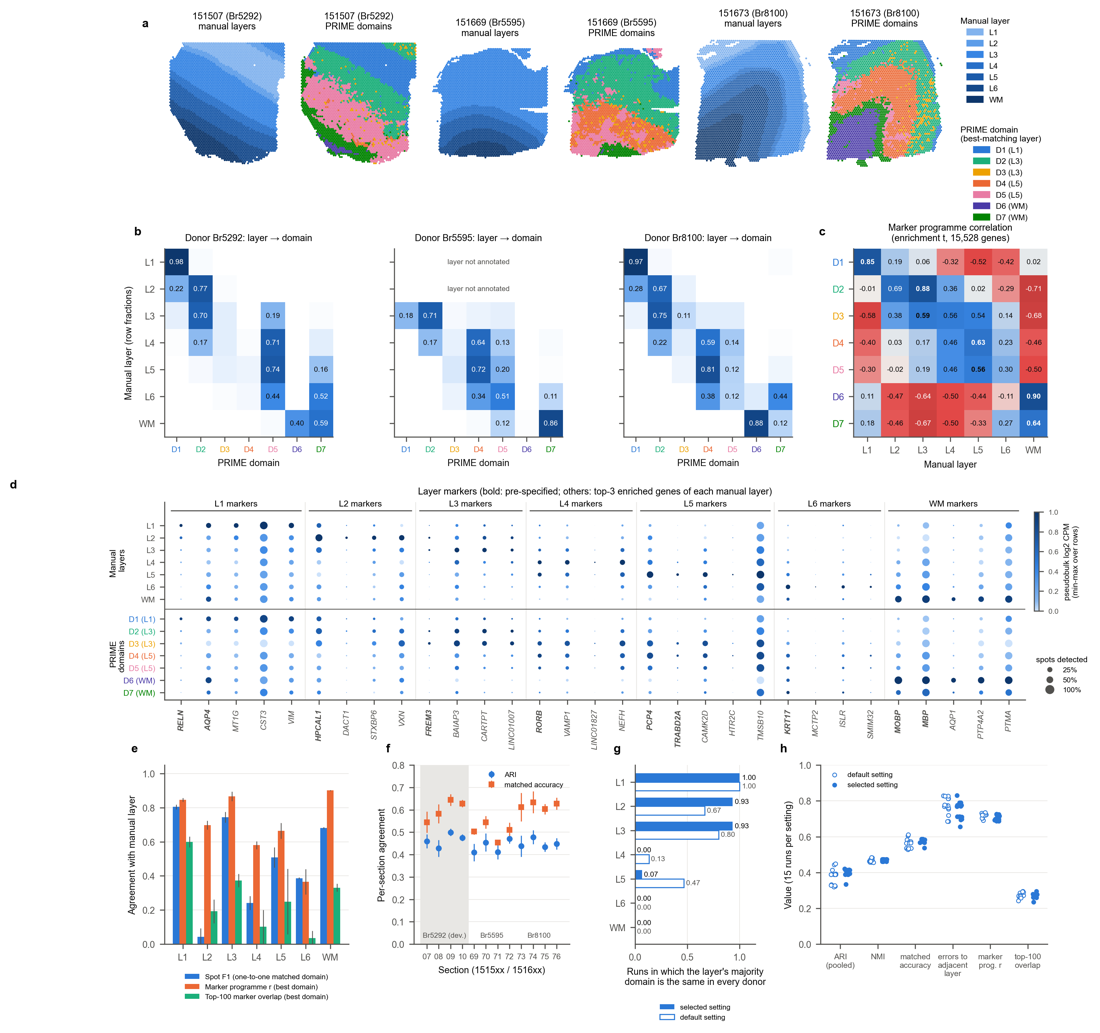

In [13]:
draw(fig_dlpfc_marker_concordance, "dlpfc_marker_concordance")